# Healthcare Patient Readmission & Data Quality Analysis

Portfolio project using the UCI **Diabetes 130-US Hospitals for Years 1999-2008** dataset. The dataset contains 101,766 hospital encounters and 47 features.

**Tools:** Python, Pandas, NumPy, Matplotlib, SQL

## Objectives
- Profile the patient/encounter population.
- Examine readmission patterns.
- Compare length of stay across readmission outcomes.
- Explore demographic/admission variables.
- Identify data-quality and missing-value issues.
- Produce evidence-based findings suitable for a healthcare analytics portfolio.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the downloaded UCI dataset from the project data folder
df = pd.read_csv("../data/diabetes_data.csv")

print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [9]:
# Check the dataset structure and data types

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (101766, 50)

Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data types:
encounter_id                int64
patient_nbr                 int64
race                          str
gender                  

In [10]:
# Check for missing values

missing_values = df.isin(["?"]).sum()

print("Columns containing '?' values:")
print(missing_values[missing_values > 0].sort_values(ascending=False))

Columns containing '?' values:
Series([], dtype: int64)


In [11]:
# Check for actual missing (NaN) values

missing_nan = df.isna().sum()

print("Columns containing missing (NaN) values:")
print(missing_nan[missing_nan > 0].sort_values(ascending=False))

Columns containing missing (NaN) values:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


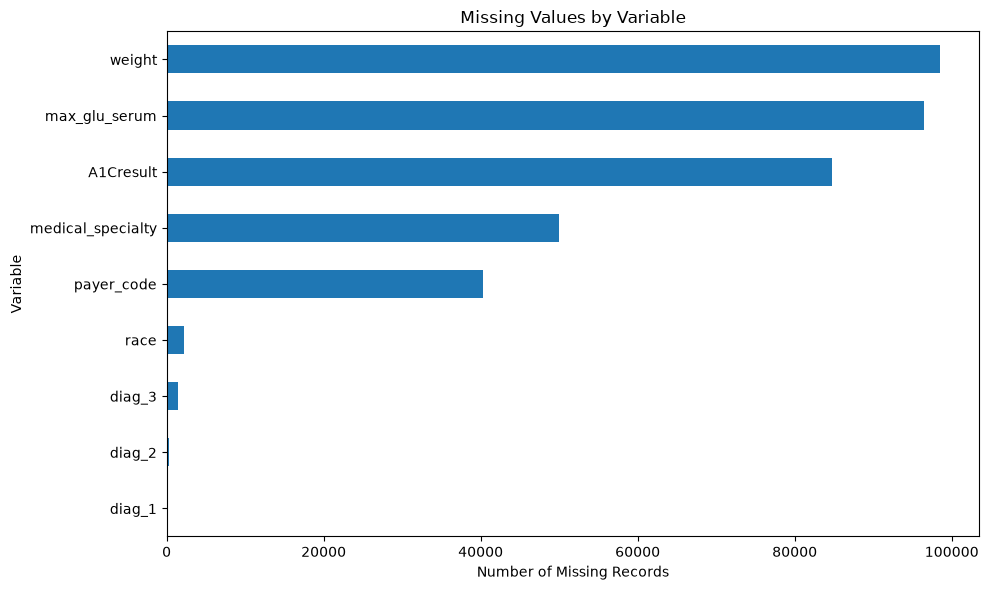

In [12]:
# Visualise missing values

missing_data = df.isna().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=True)

plt.figure(figsize=(10, 6))
missing_data.plot(kind="barh")

plt.title("Missing Values by Variable")
plt.xlabel("Number of Missing Records")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [13]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [14]:
# Check the number of unique patients

unique_patients = df["patient_nbr"].nunique()

print("Total patient records:", len(df))
print("Unique patients:", unique_patients)

Total patient records: 101766
Unique patients: 71518


In [15]:
# Check the distribution of readmission outcomes

readmission_counts = df["readmitted"].value_counts()

print("Readmission outcomes:")
print(readmission_counts)

Readmission outcomes:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


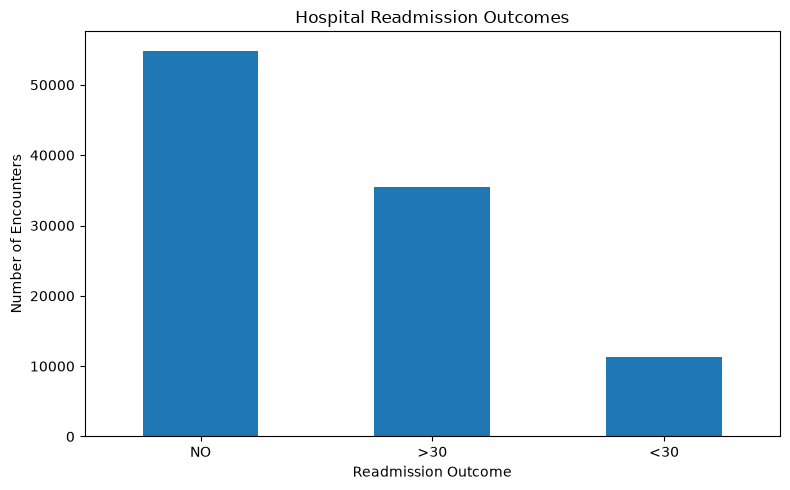

In [16]:
# Visualise readmission outcomes

readmission_counts = df["readmitted"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

readmission_counts.plot(kind="bar", ax=ax)

ax.set_title("Hospital Readmission Outcomes")
ax.set_xlabel("Readmission Outcome")
ax.set_ylabel("Number of Encounters")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
# Calculate readmission percentages

readmission_percentages = df["readmitted"].value_counts(normalize=True) * 100

print("Readmission percentages:")
print(readmission_percentages.round(2))

Readmission percentages:
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


In [18]:
# Check the distribution of patient age groups

age_counts = df["age"].value_counts().sort_index()

print("Age group distribution:")
print(age_counts)

Age group distribution:
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


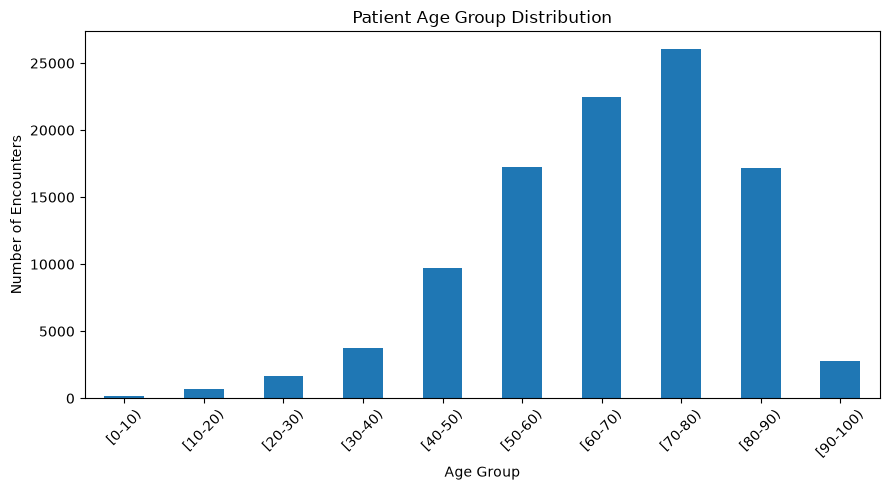

In [19]:
# Visualise patient age distribution

age_counts = df["age"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))

age_counts.plot(kind="bar", ax=ax)

ax.set_title("Patient Age Group Distribution")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Encounters")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Calculate readmission within 30 days by age group

readmission_by_age = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("age")["readmitted_under_30"]
      .mean() * 100
)

print("Readmission within 30 days by age group:")
print(readmission_by_age.round(2))

Readmission within 30 days by age group:
age
[0-10)       1.86
[10-20)      5.79
[20-30)     14.24
[30-40)     11.23
[40-50)     10.60
[50-60)      9.67
[60-70)     11.13
[70-80)     11.77
[80-90)     12.08
[90-100)    11.10
Name: readmitted_under_30, dtype: float64


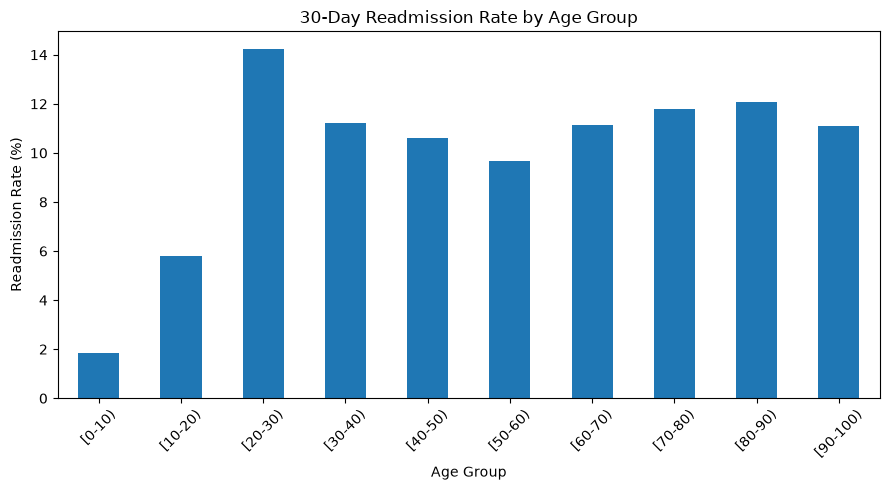

In [21]:
# Visualise 30-day readmission by age group

fig, ax = plt.subplots(figsize=(9, 5))

readmission_by_age.plot(kind="bar", ax=ax)

ax.set_title("30-Day Readmission Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Readmission Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# Check gender distribution

gender_counts = df["gender"].value_counts()

print("Gender distribution:")
print(gender_counts)

Gender distribution:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [23]:
# Calculate 30-day readmission by gender

readmission_by_gender = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("gender")["readmitted_under_30"]
      .mean() * 100
)

print("30-day readmission rate by gender:")
print(readmission_by_gender.round(2))

30-day readmission rate by gender:
gender
Female             11.25
Male               11.06
Unknown/Invalid     0.00
Name: readmitted_under_30, dtype: float64


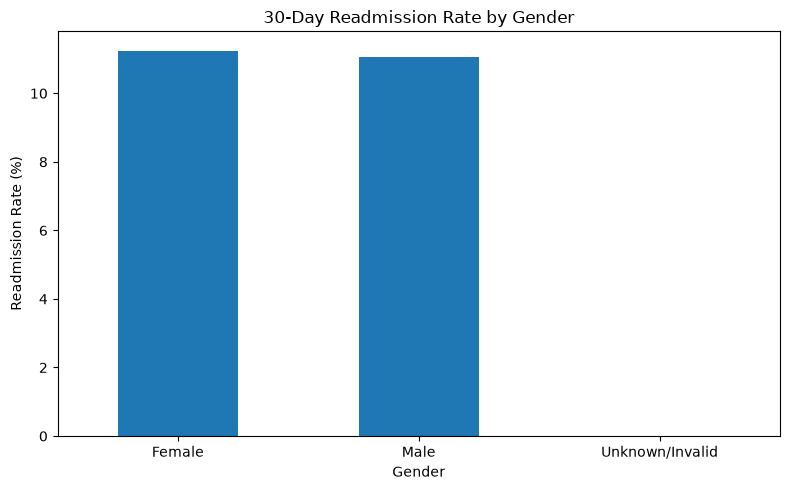

In [24]:
# Visualise 30-day readmission by gender

fig, ax = plt.subplots(figsize=(8, 5))

readmission_by_gender.plot(kind="bar", ax=ax)

ax.set_title("30-Day Readmission Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Readmission Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
# Check the distribution of hospital stay duration

stay_counts = df["time_in_hospital"].value_counts().sort_index()

print("Hospital stay duration:")
print(stay_counts)

Hospital stay duration:
time_in_hospital
1     14208
2     17224
3     17756
4     13924
5      9966
6      7539
7      5859
8      4391
9      3002
10     2342
11     1855
12     1448
13     1210
14     1042
Name: count, dtype: int64


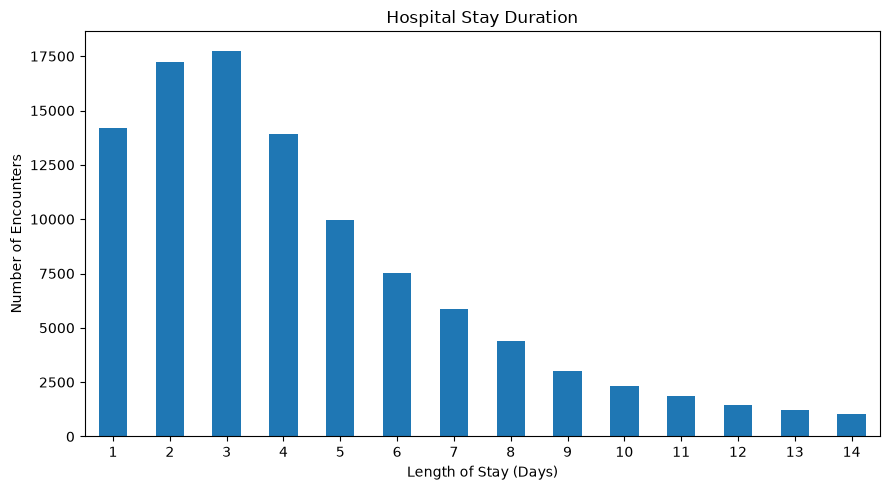

In [26]:
# Visualise hospital stay duration

fig, ax = plt.subplots(figsize=(9, 5))

stay_counts.plot(kind="bar", ax=ax)

ax.set_title("Hospital Stay Duration")
ax.set_xlabel("Length of Stay (Days)")
ax.set_ylabel("Number of Encounters")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
# Calculate 30-day readmission rate by hospital stay duration

readmission_by_stay = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("time_in_hospital")["readmitted_under_30"]
      .mean() * 100
)

print("30-day readmission rate by hospital stay:")
print(readmission_by_stay.round(2))

30-day readmission rate by hospital stay:
time_in_hospital
1      8.18
2      9.94
3     10.67
4     11.81
5     12.03
6     12.59
7     12.83
8     14.23
9     13.72
10    14.35
11    10.51
12    13.33
13    12.31
14    12.96
Name: readmitted_under_30, dtype: float64


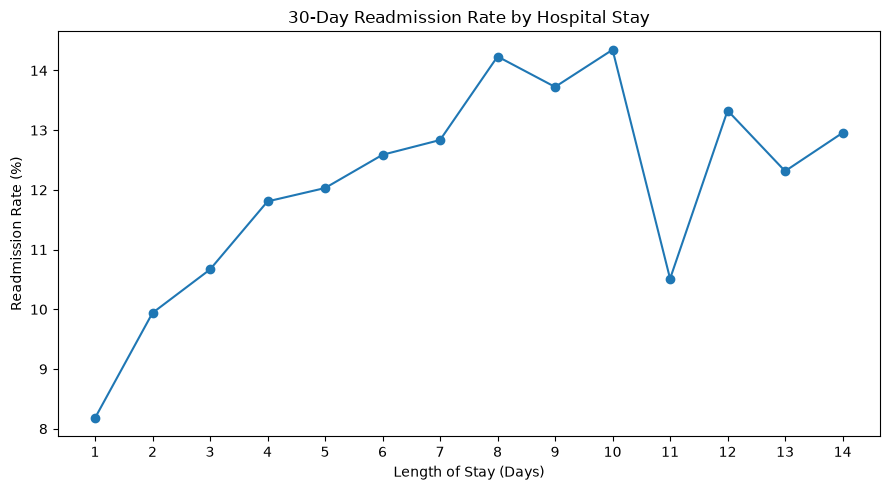

In [28]:
# Visualise 30-day readmission rate by hospital stay

fig, ax = plt.subplots(figsize=(9, 5))

readmission_by_stay.plot(kind="line", marker="o", ax=ax)

ax.set_title("30-Day Readmission Rate by Hospital Stay")
ax.set_xlabel("Length of Stay (Days)")
ax.set_ylabel("Readmission Rate (%)")

plt.xticks(range(1, 15))
plt.tight_layout()
plt.show()

In [29]:
# Calculate the average hospital stay

average_stay = df["time_in_hospital"].mean()

print("Average hospital stay:", round(average_stay, 2), "days")

Average hospital stay: 4.4 days


In [30]:
# Check the distribution of number of medications

medication_counts = df["num_medications"].describe()

print("Number of medications per encounter:")
print(medication_counts.round(2))

Number of medications per encounter:
count    101766.00
mean         16.02
std           8.13
min           1.00
25%          10.00
50%          15.00
75%          20.00
max          81.00
Name: num_medications, dtype: float64


In [31]:
# Calculate 30-day readmission rate by number of medications

readmission_by_medications = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("num_medications")["readmitted_under_30"]
      .mean() * 100
)

print("30-day readmission rate by number of medications:")
print(readmission_by_medications.round(2))

30-day readmission rate by number of medications:
num_medications
1       4.20
2       8.30
3       7.22
4       8.05
5       7.44
       ...  
72    100.00
74      0.00
75      0.00
79      0.00
81    100.00
Name: readmitted_under_30, Length: 75, dtype: float64


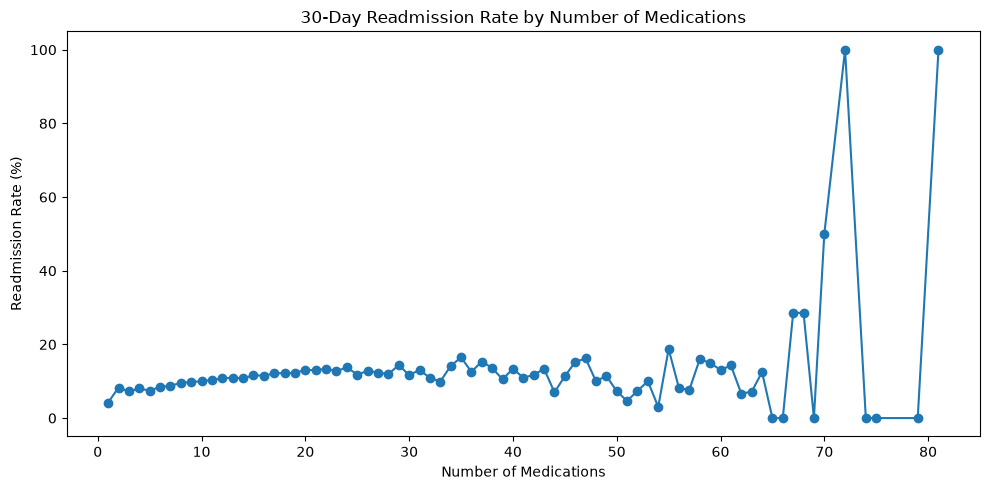

In [32]:
# Visualise 30-day readmission rate by number of medications

fig, ax = plt.subplots(figsize=(10, 5))

readmission_by_medications.plot(kind="line", marker="o", ax=ax)

ax.set_title("30-Day Readmission Rate by Number of Medications")
ax.set_xlabel("Number of Medications")
ax.set_ylabel("Readmission Rate (%)")

plt.tight_layout()
plt.show()

In [33]:
# Check the distribution of number of diagnoses

diagnosis_counts = df["number_diagnoses"].value_counts().sort_index()

print("Number of diagnoses per encounter:")
print(diagnosis_counts)

Number of diagnoses per encounter:
number_diagnoses
1       219
2      1023
3      2835
4      5537
5     11393
6     10161
7     10393
8     10616
9     49474
10       17
11       11
12        9
13       16
14        7
15       10
16       45
Name: count, dtype: int64


In [34]:
# Calculate 30-day readmission rate by number of diagnoses

readmission_by_diagnoses = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("number_diagnoses")["readmitted_under_30"]
      .mean() * 100
)

print("30-day readmission rate by number of diagnoses:")
print(readmission_by_diagnoses.round(2))

30-day readmission rate by number of diagnoses:
number_diagnoses
1      5.94
2      6.06
3      7.37
4      8.25
5      9.15
6     10.41
7     10.77
8     11.81
9     12.38
10    17.65
11    27.27
12    11.11
13    18.75
14    14.29
15    20.00
16     8.89
Name: readmitted_under_30, dtype: float64


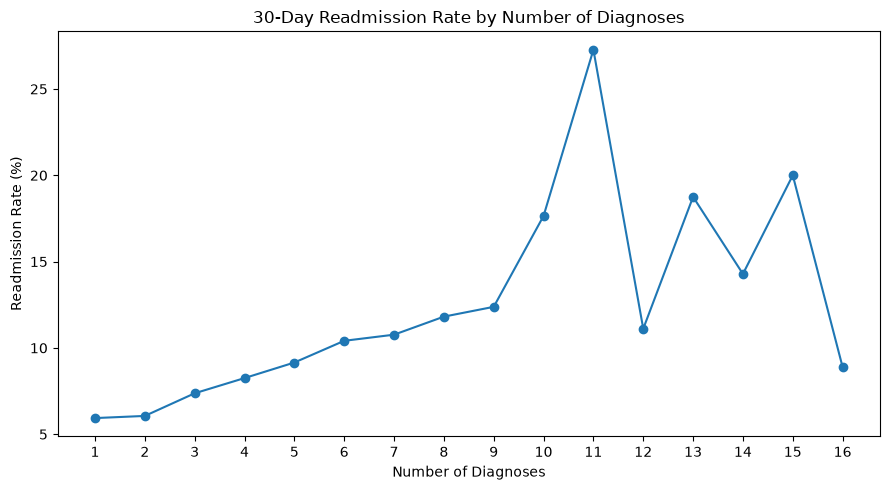

In [35]:
# Visualise 30-day readmission rate by number of diagnoses

fig, ax = plt.subplots(figsize=(9, 5))

readmission_by_diagnoses.plot(kind="line", marker="o", ax=ax)

ax.set_title("30-Day Readmission Rate by Number of Diagnoses")
ax.set_xlabel("Number of Diagnoses")
ax.set_ylabel("Readmission Rate (%)")

plt.xticks(range(1, 17))
plt.tight_layout()
plt.show()

In [36]:
# Calculate 30-day readmission rate by number of emergency visits

readmission_by_emergency = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("number_emergency")["readmitted_under_30"]
      .mean() * 100
)

print("30-day readmission rate by number of emergency visits:")
print(readmission_by_emergency.round(2))

30-day readmission rate by number of emergency visits:
number_emergency
0      10.47
1      14.35
2      18.27
3      20.28
4      30.75
5      24.48
6      23.40
7      26.03
8      32.00
9      36.36
10     35.29
11     21.74
12     20.00
13     33.33
14      0.00
15     33.33
16     40.00
18     20.00
19     50.00
20     50.00
21     50.00
22     50.00
24      0.00
25      0.00
28    100.00
29      0.00
37      0.00
42      0.00
46      0.00
54      0.00
63      0.00
64    100.00
76      0.00
Name: readmitted_under_30, dtype: float64


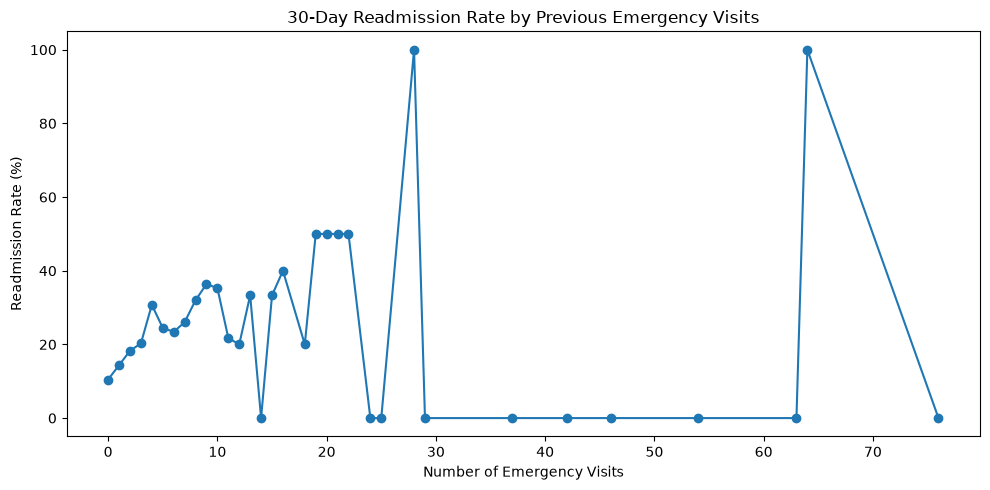

In [37]:
# Visualise 30-day readmission rate by number of emergency visits

fig, ax = plt.subplots(figsize=(10, 5))

readmission_by_emergency.plot(kind="line", marker="o", ax=ax)

ax.set_title("30-Day Readmission Rate by Previous Emergency Visits")
ax.set_xlabel("Number of Emergency Visits")
ax.set_ylabel("Readmission Rate (%)")

plt.tight_layout()
plt.show()

In [38]:
# Calculate 30-day readmission rate by number of previous inpatient visits

readmission_by_inpatient = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("number_inpatient")["readmitted_under_30"]
      .mean() * 100
)

print("30-day readmission rate by number of previous inpatient visits:")
print(readmission_by_inpatient.round(2))

30-day readmission rate by number of previous inpatient visits:
number_inpatient
0       8.44
1      12.92
2      17.43
3      20.29
4      23.61
5      31.40
6      34.58
7      35.45
8      44.37
9      42.34
10     42.62
11     67.35
12     50.00
13     50.00
14     40.00
15    100.00
16     33.33
17    100.00
18      0.00
19     50.00
21    100.00
Name: readmitted_under_30, dtype: float64


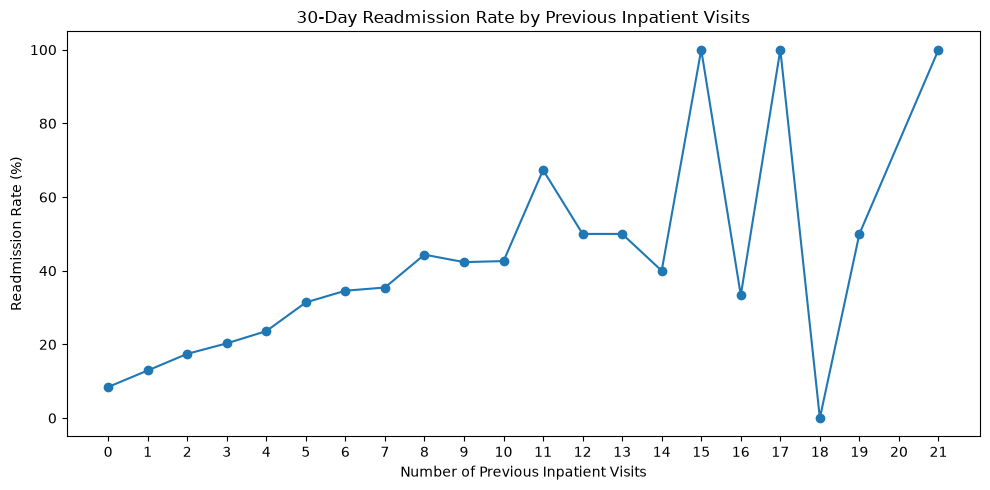

In [39]:
# Visualise 30-day readmission rate by previous inpatient visits

fig, ax = plt.subplots(figsize=(10, 5))

readmission_by_inpatient.plot(kind="line", marker="o", ax=ax)

ax.set_title("30-Day Readmission Rate by Previous Inpatient Visits")
ax.set_xlabel("Number of Previous Inpatient Visits")
ax.set_ylabel("Readmission Rate (%)")

plt.xticks(range(0, 22))
plt.tight_layout()
plt.show()

In [40]:
# Calculate 30-day readmission rate by number of previous outpatient visits

readmission_by_outpatient = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("number_outpatient")["readmitted_under_30"]
      .mean() * 100
)

print("30-day readmission rate by number of previous outpatient visits:")
print(readmission_by_outpatient.round(2))

30-day readmission rate by number of previous outpatient visits:
number_outpatient
0      10.67
1      13.92
2      13.75
3      12.29
4      15.10
5      11.82
6      13.20
7      15.48
8       5.10
9      15.66
10      8.77
11     14.29
12     20.00
13     19.35
14     17.86
15     10.00
16      0.00
17     12.50
18      0.00
19     33.33
20      0.00
21      0.00
22     20.00
23     50.00
24      0.00
25      0.00
26      0.00
27      0.00
28      0.00
29      0.00
33      0.00
34      0.00
35      0.00
36      0.00
37      0.00
38      0.00
39      0.00
40    100.00
42      0.00
Name: readmitted_under_30, dtype: float64


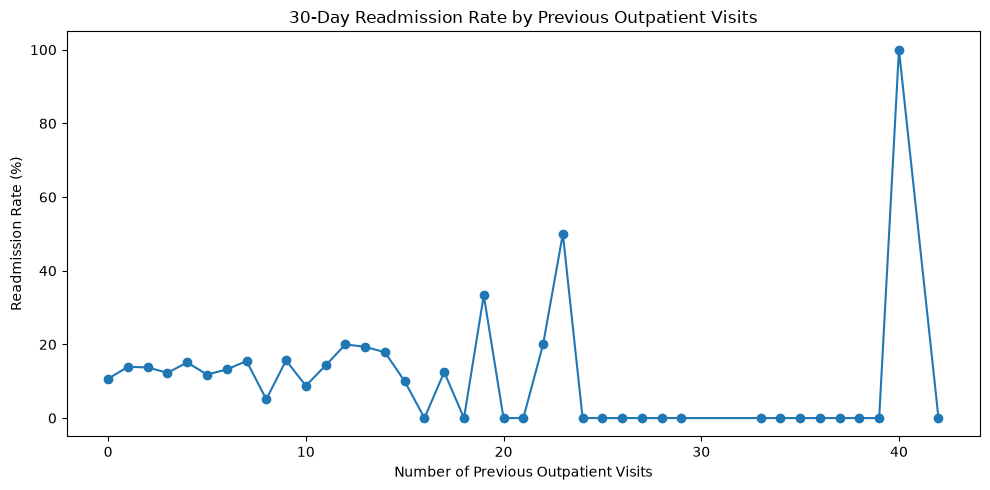

In [41]:
# Visualise 30-day readmission rate by previous outpatient visits

fig, ax = plt.subplots(figsize=(10, 5))

readmission_by_outpatient.plot(kind="line", marker="o", ax=ax)

ax.set_title("30-Day Readmission Rate by Previous Outpatient Visits")
ax.set_xlabel("Number of Previous Outpatient Visits")
ax.set_ylabel("Readmission Rate (%)")

plt.tight_layout()
plt.show()

In [42]:
# Calculate 30-day readmission rate by diabetes medication status

readmission_by_med_status = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("diabetesMed")["readmitted_under_30"]
      .mean() * 100
)

print("30-day readmission rate by diabetes medication status:")
print(readmission_by_med_status.round(2))

30-day readmission rate by diabetes medication status:
diabetesMed
No      9.60
Yes    11.63
Name: readmitted_under_30, dtype: float64


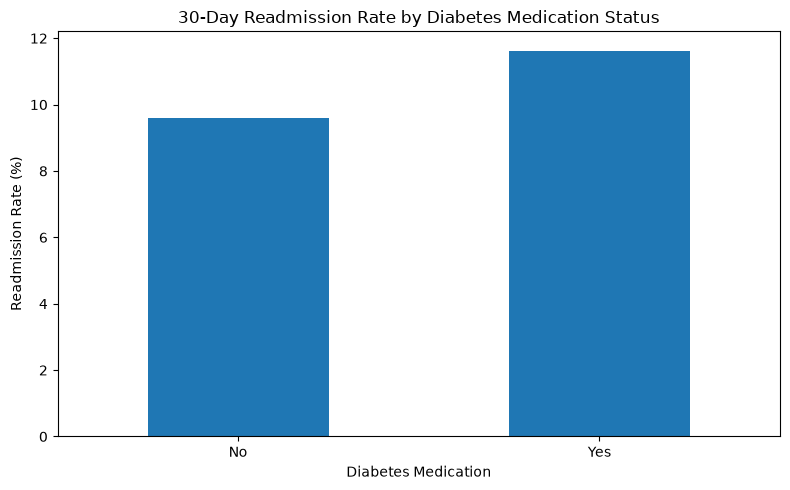

In [43]:
# Visualise 30-day readmission rate by diabetes medication status

fig, ax = plt.subplots(figsize=(8, 5))

readmission_by_med_status.plot(kind="bar", ax=ax)

ax.set_title("30-Day Readmission Rate by Diabetes Medication Status")
ax.set_xlabel("Diabetes Medication")
ax.set_ylabel("Readmission Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 1. Initial data-quality profile


In [4]:
# Convert UCI missing-value marker to NaN for analysis
df = df.replace('?', np.nan)

quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean()*100).round(2),
    'unique_values': df.nunique(dropna=True)
}).sort_values('missing_pct', ascending=False)

quality.head(15)


,dtype,missing_count,missing_pct,unique_values
weight,str,98569,96.86,9
max_glu_serum,str,96420,94.75,3
A1Cresult,str,84748,83.28,3
medical_specialty,str,49949,49.08,72
payer_code,str,40256,39.56,17
race,str,2273,2.23,5
diag_3,str,1423,1.40,789
diag_2,str,358,0.35,748
diag_1,str,21,0.02,716
patient_nbr,int64,0,0.00,71518


In [44]:
# Calculate 30-day readmission rate by diabetes medication change

readmission_by_med_change = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("change")["readmitted_under_30"]
      .mean() * 100
)

print("30-day readmission rate by diabetes medication change:")
print(readmission_by_med_change.round(2))

30-day readmission rate by diabetes medication change:
change
Ch    11.82
No    10.59
Name: readmitted_under_30, dtype: float64


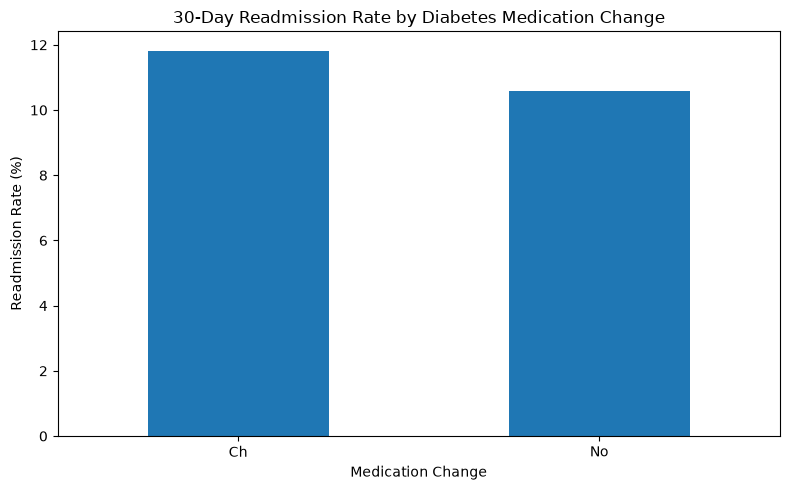

In [45]:
# Visualise 30-day readmission rate by diabetes medication change

fig, ax = plt.subplots(figsize=(8, 5))

readmission_by_med_change.plot(kind="bar", ax=ax)

ax.set_title("30-Day Readmission Rate by Diabetes Medication Change")
ax.set_xlabel("Medication Change")
ax.set_ylabel("Readmission Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
# Calculate 30-day readmission rate by HbA1c test result

readmission_by_a1c = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("A1Cresult")["readmitted_under_30"]
      .mean() * 100
)

print("30-day readmission rate by HbA1c test result:")
print(readmission_by_a1c.round(2))

30-day readmission rate by HbA1c test result:
A1Cresult
>7      10.05
>8       9.87
Norm     9.66
Name: readmitted_under_30, dtype: float64


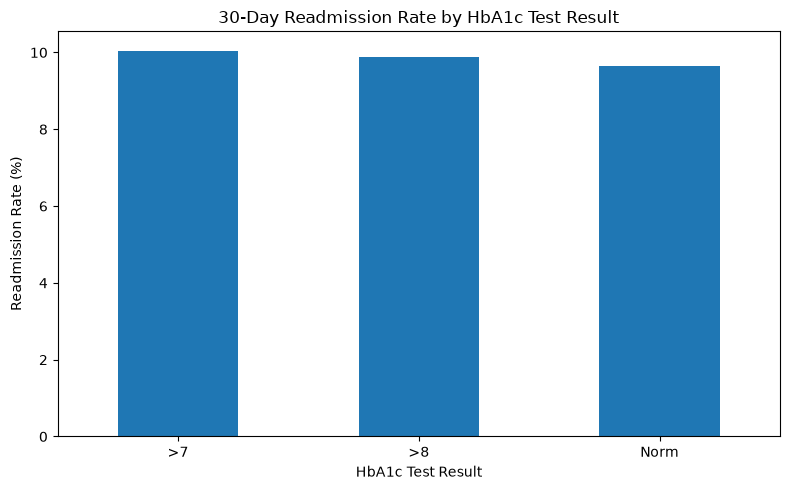

In [47]:
# Visualise 30-day readmission rate by HbA1c test result

fig, ax = plt.subplots(figsize=(8, 5))

readmission_by_a1c.plot(kind="bar", ax=ax)

ax.set_title("30-Day Readmission Rate by HbA1c Test Result")
ax.set_xlabel("HbA1c Test Result")
ax.set_ylabel("Readmission Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Readmission distribution


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


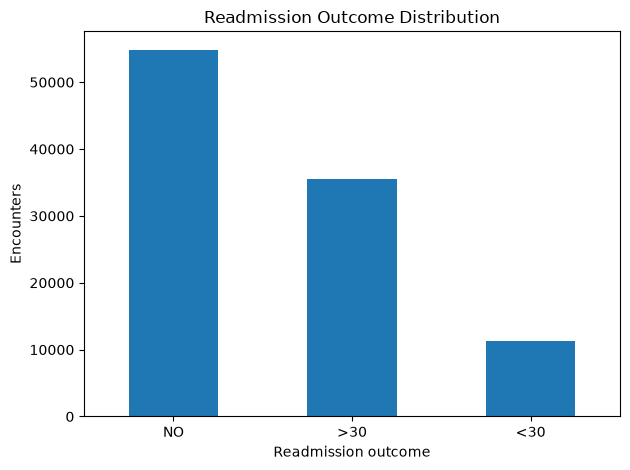

In [5]:
readmission_counts = df['readmitted'].value_counts(dropna=False)
print(readmission_counts)

ax = readmission_counts.plot(kind='bar', title='Readmission Outcome Distribution')
ax.set_xlabel('Readmission outcome')
ax.set_ylabel('Encounters')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [48]:
# Calculate 30-day readmission rate by insulin treatment

readmission_by_insulin = (
    df.assign(readmitted_under_30=df["readmitted"] == "<30")
      .groupby("insulin")["readmitted_under_30"]
      .mean() * 100
)

print("30-day readmission rate by insulin treatment:")
print(readmission_by_insulin.round(2))

30-day readmission rate by insulin treatment:
insulin
Down      13.90
No        10.04
Steady    11.13
Up        12.99
Name: readmitted_under_30, dtype: float64


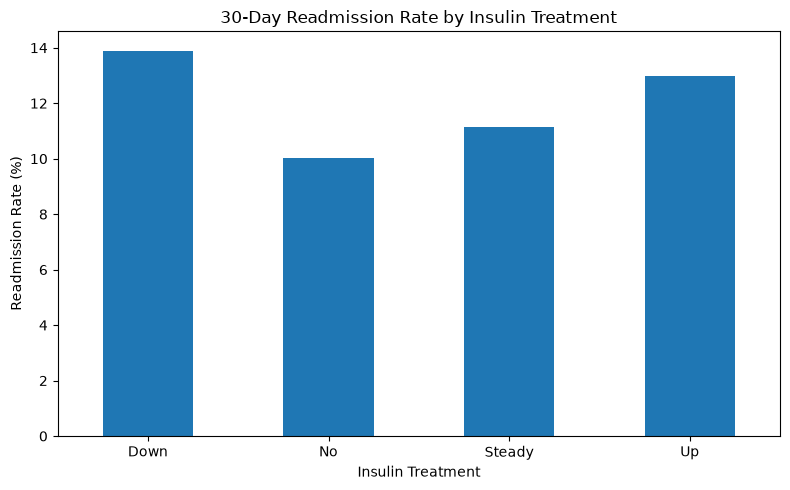

In [49]:
# Visualise 30-day readmission rate by insulin treatment

fig, ax = plt.subplots(figsize=(8, 5))

readmission_by_insulin.plot(kind="bar", ax=ax)

ax.set_title("30-Day Readmission Rate by Insulin Treatment")
ax.set_xlabel("Insulin Treatment")
ax.set_ylabel("Readmission Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [50]:
# Calculate correlations between selected numerical variables

numeric_variables = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

correlation_matrix = df[numeric_variables].corr()

print("Correlation matrix:")
print(correlation_matrix.round(2))

Correlation matrix:
                    time_in_hospital  num_lab_procedures  num_procedures  \
time_in_hospital                1.00                0.32            0.19   
num_lab_procedures              0.32                1.00            0.06   
num_procedures                  0.19                0.06            1.00   
num_medications                 0.47                0.27            0.39   
number_outpatient              -0.01               -0.01           -0.02   
number_emergency               -0.01               -0.00           -0.04   
number_inpatient                0.07                0.04           -0.07   
number_diagnoses                0.22                0.15            0.07   

                    num_medications  number_outpatient  number_emergency  \
time_in_hospital               0.47              -0.01             -0.01   
num_lab_procedures             0.27              -0.01             -0.00   
num_procedures                 0.39              -0.02             

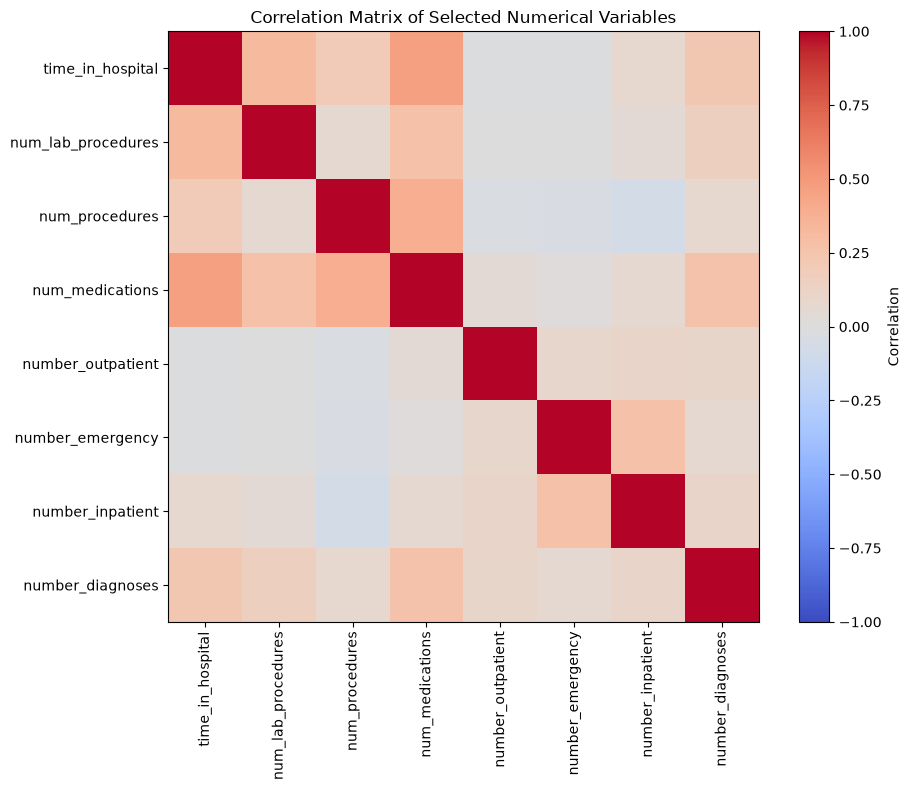

In [51]:
# Visualise correlations between numerical variables

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, rotation=90)
ax.set_yticklabels(correlation_matrix.columns)

ax.set_title("Correlation Matrix of Selected Numerical Variables")

fig.colorbar(im, ax=ax, label="Correlation")

plt.tight_layout()
plt.show()

In [52]:
# Create a binary 30-day readmission indicator

df["readmitted_30_days"] = (df["readmitted"] == "<30").astype(int)

print("30-day readmission indicator:")
print(df["readmitted_30_days"].value_counts())

30-day readmission indicator:
readmitted_30_days
0    90409
1    11357
Name: count, dtype: int64


In [53]:
# Calculate the overall 30-day readmission rate

overall_readmission_rate = df["readmitted_30_days"].mean() * 100

print("Overall 30-day readmission rate:", round(overall_readmission_rate, 2), "%")

Overall 30-day readmission rate: 11.16 %


In [54]:
# Create a summary of key readmission findings

summary = pd.DataFrame({
    "Metric": [
        "Overall 30-day readmission rate",
        "Average hospital stay (days)",
        "Unique patients",
        "Total encounters"
    ],
    "Value": [
        round(overall_readmission_rate, 2),
        round(average_stay, 2),
        unique_patients,
        len(df)
    ]
})

summary

,Metric,Value
0,Overall 30-day readmission rate,11.16
1,Average hospital stay (days),4.40
2,Unique patients,71518.00
3,Total encounters,101766.00


In [55]:
# Create a SQLite database from the cleaned dataset

import sqlite3

conn = sqlite3.connect("../data/readmission_analysis.db")

df.to_sql("diabetes", conn, if_exists="replace", index=False)

print("SQLite database created successfully.")

SQLite database created successfully.


## 3. Length of stay vs readmission


            count  mean  median  min  max
readmitted                               
<30         11357  4.77     4.0    1   14
>30         35545  4.50     4.0    1   14
NO          54864  4.25     3.0    1   14


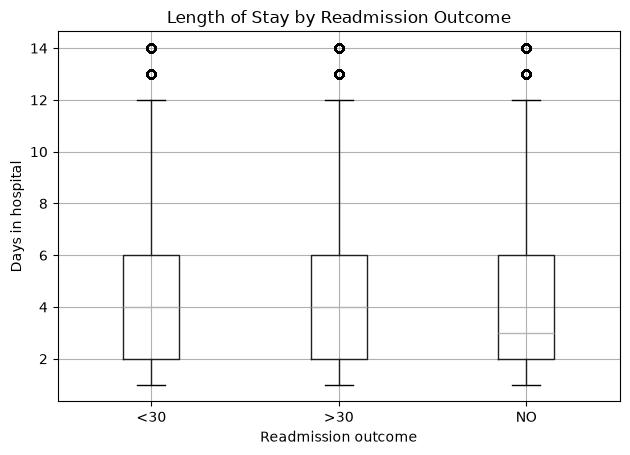

In [6]:
stay_summary = df.groupby('readmitted')['time_in_hospital'].agg(['count','mean','median','min','max']).round(2)
print(stay_summary)

ax = df.boxplot(column='time_in_hospital', by='readmitted')
ax.set_title('Length of Stay by Readmission Outcome')
ax.set_xlabel('Readmission outcome')
ax.set_ylabel('Days in hospital')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 4. Age and admission patterns


readmitted    <30    >30     NO
age                            
[0-10)       1.86  16.15  81.99
[10-20)      5.79  32.42  61.79
[20-30)     14.24  30.78  54.98
[30-40)     11.23  31.44  57.32
[40-50)     10.60  33.85  55.55
[50-60)      9.67  34.29  56.04
[60-70)     11.13  35.12  53.75
[70-80)     11.77  36.35  51.88
[80-90)     12.08  36.19  51.73
[90-100)    11.10  28.93  59.97


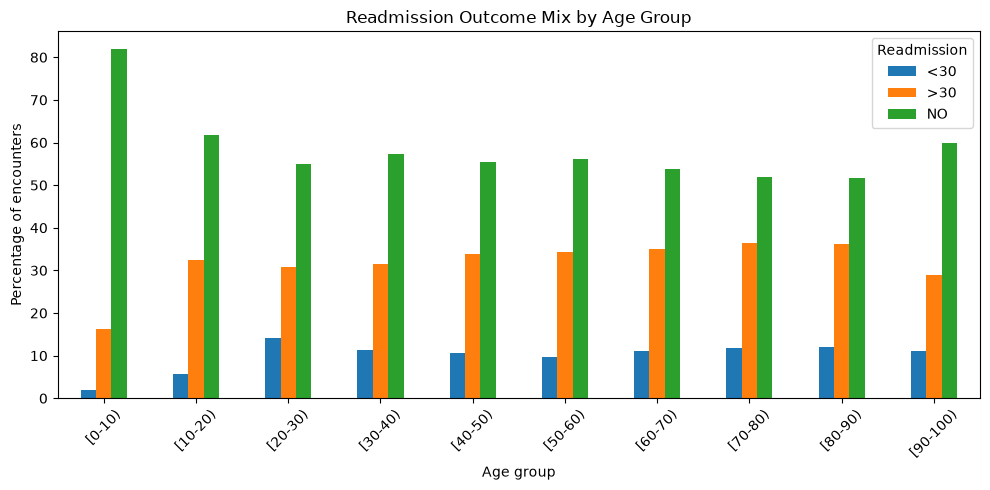

In [7]:
age_readmission = pd.crosstab(df['age'], df['readmitted'], normalize='index').mul(100).round(2)
print(age_readmission)

fig, ax = plt.subplots(figsize=(10,5))
age_readmission.plot(kind='bar', ax=ax)
ax.set_title('Readmission Outcome Mix by Age Group')
ax.set_xlabel('Age group')
ax.set_ylabel('Percentage of encounters')
ax.legend(title='Readmission')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Data-quality checks


In [8]:
checks = {
    'duplicate_rows': int(df.duplicated().sum()),
    'missing_values_total': int(df.isna().sum().sum()),
    'encounter_id_duplicates': int(df['encounter_id'].duplicated().sum()),
    'patient_id_unique_count': int(df['patient_nbr'].nunique()),
}
checks


{'duplicate_rows': 0,
 'missing_values_total': 374017,
 'encounter_id_duplicates': 0,
 'patient_id_unique_count': 71518}

## 6. Optional modelling extension
For a later iteration, the cleaned dataset can be transformed into a binary target for early readmission and used for logistic regression or tree-based classification. Keep the first portfolio version focused on data analysis and data quality rather than overclaiming predictive performance.


## 7. Portfolio conclusions

* The overall 30-day readmission rate was **11.16%**, with **11,357 of 101,766 encounters** resulting in readmission within 30 days.
* The dataset contained **101,766 hospital encounters involving 71,518 unique patients**, providing a substantial sample for healthcare data analysis.
* The average hospital stay was **4.40 days**. The 30-day readmission rate was **8.18% for one-day stays** and increased to **14.35% for ten-day stays**, although the relationship was not perfectly consistent across all lengths of stay.
* The analysis identified substantial missing data. **98,569 weight records** were missing, along with **49,949 medical specialty records** and **40,256 payer code records**. These limitations should be considered when interpreting findings involving these variables.
* The dataset covers hospital encounters from **1999–2008**, so the findings describe historical healthcare activity and may not directly represent current hospital populations or practices.



In [56]:
import matplotlib.pyplot as plt
from pathlib import Path

folder = Path("../visualisations")
folder.mkdir(exist_ok=True)

for i, fig_num in enumerate(plt.get_fignums(), start=1):
    fig = plt.figure(fig_num)
    fig.savefig(folder / f"chart_{i}.png", dpi=200, bbox_inches="tight")

print("Charts saved to visualisations folder.")

Charts saved to visualisations folder.
